In [2]:
!pip install wordcloud beautifulsoup4 matplotlib pandas



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import glob
import os
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

def clean_text(text):
    return BeautifulSoup(str(text), "html.parser").get_text().strip()

def load_all_json(folder):
    all_files = glob.glob(os.path.join(folder, "*.json"))
    dfs = [pd.read_json(file) for file in all_files]
    return pd.concat(dfs, ignore_index=True)

def sanitize_filename(name):
    return ''.join(c if c.isalnum() or c in (' ', '_') else '_' for c in name).replace(' ', '_')

def generate_wordclouds(df, output_dir):
    df['clean_text'] = df['text'].apply(clean_text)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    summary = []

    for cat in df['new_main_category'].dropna().unique():
        df_cat = df[df['new_main_category'] == cat]
        for tag in df_cat['tag'].dropna().unique():
            df_tag = df_cat[df_cat['tag'] == tag]
            for sent in df_tag['sentiment'].dropna().unique():
                subset = df_tag[df_tag['sentiment'] == sent]

                if not subset.empty:
                    text = ' '.join(subset['clean_text'].tolist())

                    wordcloud = WordCloud(
                        width=800,
                        height=400,
                        background_color='white',
                        stopwords=STOPWORDS
                    ).generate(text)

                    filename = f"{sanitize_filename(cat)}_{sanitize_filename(tag)}_{sanitize_filename(sent)}.png"
                    path = os.path.join(output_dir, filename)
                    wordcloud.to_file(path)

                    summary.append({
                        'category': cat,
                        'tag': tag,
                        'sentiment': sent,
                        'review_count': len(subset),
                        'wordcloud_file': filename
                    })

    return pd.DataFrame(summary)


In [2]:
import pandas as pd
import json

def load_json_file(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data)



In [11]:
import pandas as pd

input_file = "data/split_by_category/Skincare.json"
df = pd.read_json(input_file)


FileNotFoundError: File data/split_by_category/Skincare.json does not exist

In [ ]:
from IPython.display import Image, display

# แสดงตัวอย่าง wordcloud 1 ภาพ
example_path = os.path.join(output_folder, summary_df.iloc[0]['wordcloud_file'])
display(Image(filename=example_path))


In [12]:
from IPython.display import Image, display, HTML
import os

def display_wordclouds_grouped(summary_df, output_folder):
    for cat in summary_df['category'].unique():
        display(HTML(f"<h2 style='color: steelblue;'>Category: {cat}</h2>"))

        df_cat = summary_df[summary_df['category'] == cat]

        for tag in df_cat['tag'].unique():
            display(HTML(f"<h3 style='color: darkgreen;'>Tag: {tag}</h3>"))

            df_tag = df_cat[df_cat['tag'] == tag]

            for sent in df_tag['sentiment'].unique():
                df_sent = df_tag[df_tag['sentiment'] == sent]

                if not df_sent.empty:
                    file_path = os.path.join(output_folder, df_sent.iloc[0]['wordcloud_file'])
                    display(HTML(f"<b>Sentiment:</b> {sent}"))
                    display(Image(filename=file_path))



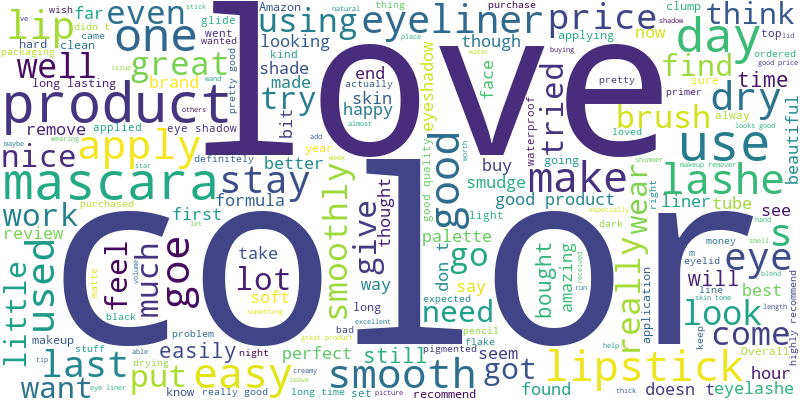

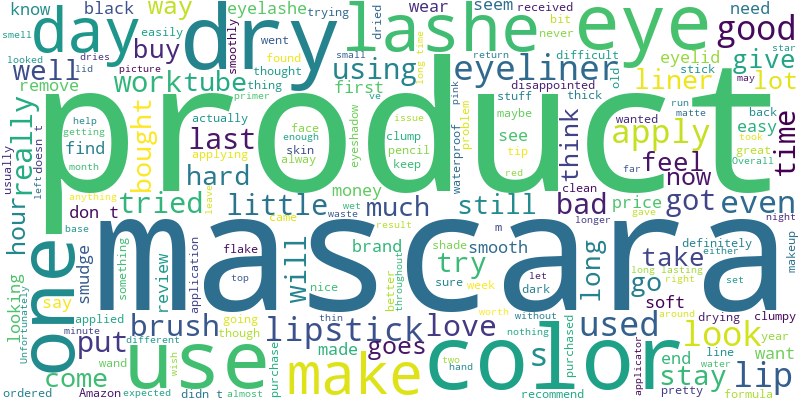

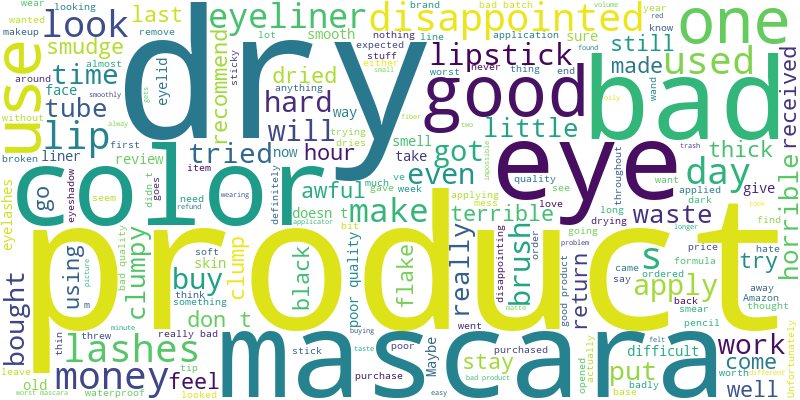

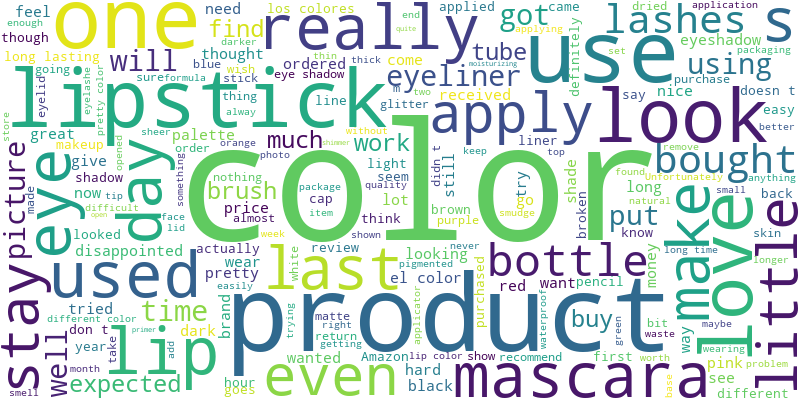

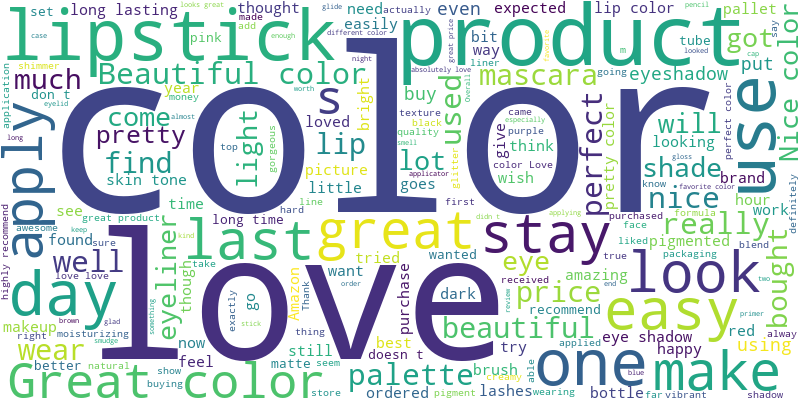

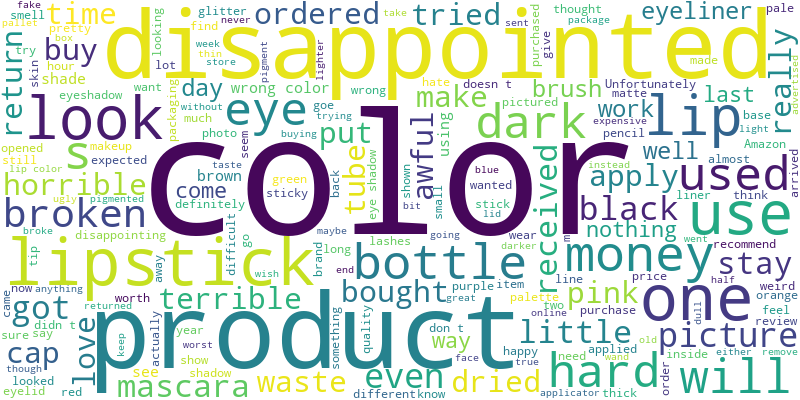

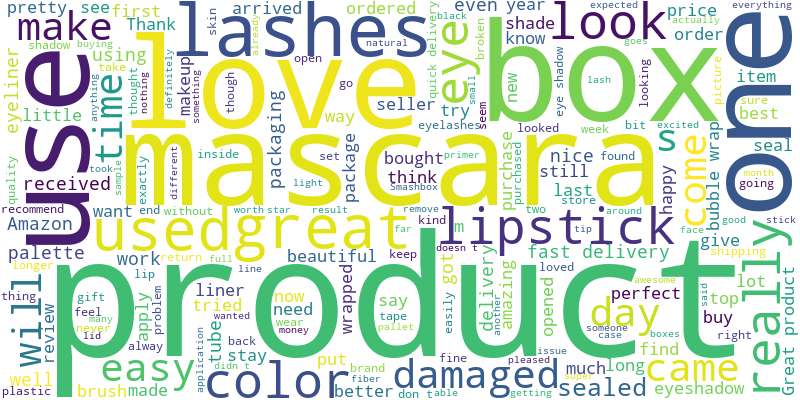

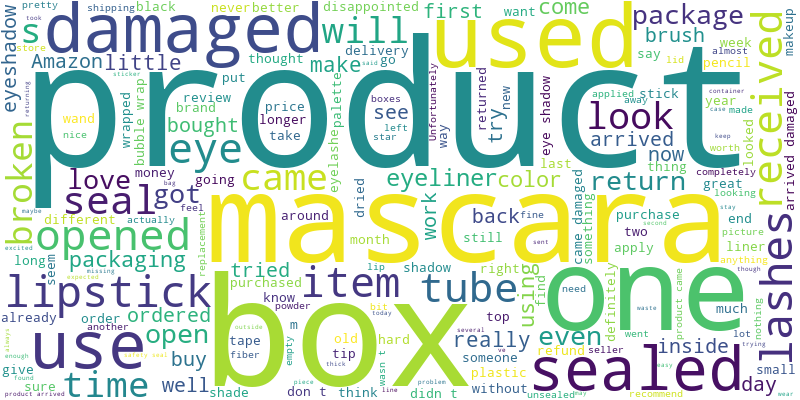

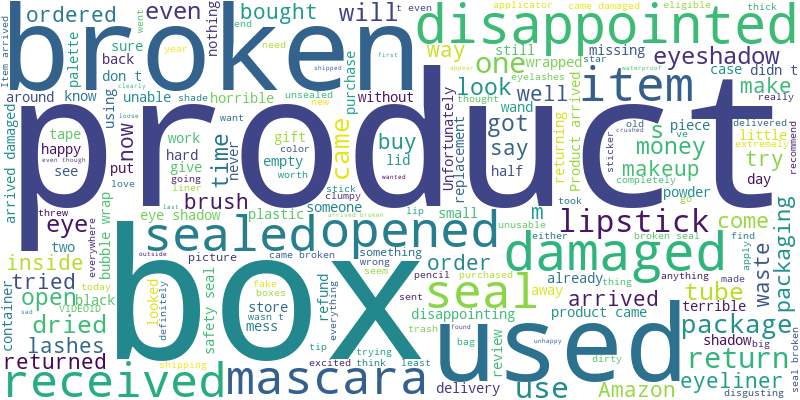

In [13]:
display_wordclouds_grouped(summary_df, output_folder)
